<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning </b></center>

<center><b><h1>Lab - 11</b></center>    
<pre>    


## Dataset: `StudentsPerformance.csv`
## 1. Import Libraries: Import KMeans from `sklearn.cluster.`

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2. Load Dataset: Load the student dataset.

In [4]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# 3. Feature Selection: 
**Select two relevant columns for clustering to visualize (e.g., GPA vs IQ).**

In [5]:
X = df[['math score', 'reading score']]

# 4. Scaling: Standardize the features.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Scatter Plot: Visualize the raw data points before clustering.

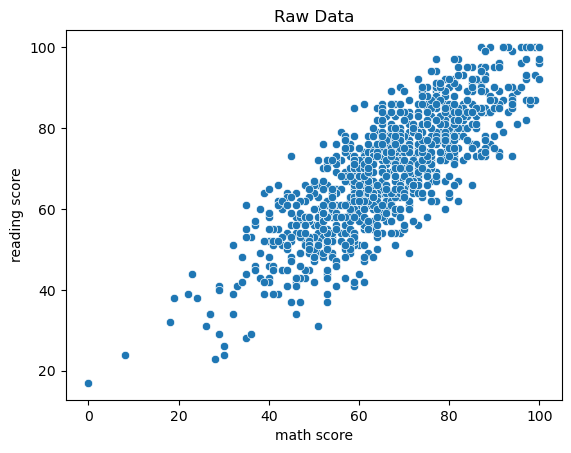

In [31]:
sns.scatterplot(
    x='math score',
    y='reading score',
    data=df)

plt.title("Raw Data")
plt.show()

# 6. Init K-Means: Initialize KMeans with n_clusters=2.

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42)

# 7. Fit Model: Fit the model to the data.

In [10]:
kmeans.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

# 8. Centroids: Print the coordinates of the cluster centroids.

In [12]:
print(kmeans.cluster_centers_)

[[-0.81708786 -0.83033943]
 [ 0.70166281  0.71304241]]


# 9. Elbow Method: Calculate WCSS (Within-Cluster Sum of Square) for K=1 to 10.

In [14]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# 10. Plot Elbow: Plot WCSS vs K to find the "elbow"

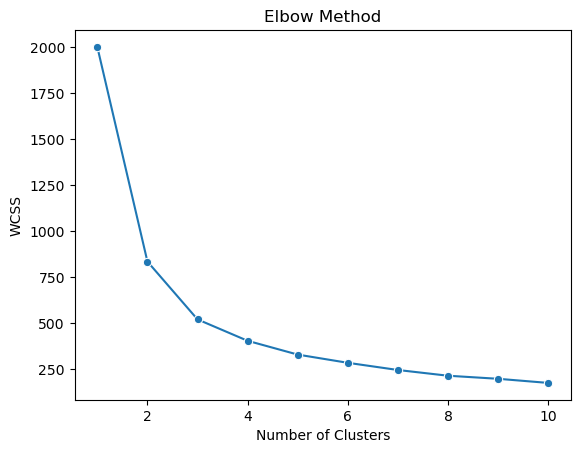

In [32]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# 11.  Optimal Clustering: Retrain KMeans with the optimal K found.

In [19]:
optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 12.  Prediction: Predict the cluster labels for the dataset.

In [21]:
print(labels)

[0 1 1 2 1 1 1 2 0 2 2 2 0 0 2 0 1 2 2 2 0 0 2 0 0 0 0 0 0 0 0 0 0 2 1 1 1
 2 1 2 0 0 2 0 2 0 0 0 0 1 2 0 2 1 1 2 1 2 0 2 1 2 0 0 0 0 2 0 0 2 0 0 2 0
 2 2 2 1 0 0 2 2 2 0 2 1 1 0 0 1 0 2 0 2 1 1 0 0 0 0 0 0 1 2 1 0 1 0 0 0 1
 0 2 2 1 1 1 1 2 0 1 1 1 0 1 1 0 0 1 2 1 2 1 1 1 2 2 0 0 0 0 0 2 2 1 2 1 0
 0 1 0 0 0 2 0 1 0 0 0 0 1 1 2 2 1 1 2 0 1 0 0 1 1 0 2 1 2 0 0 1 0 2 2 0 2
 0 1 0 2 1 0 1 0 0 1 2 0 2 2 1 1 0 0 0 2 0 0 1 1 0 1 2 2 2 1 1 1 2 0 0 0 1
 0 1 0 2 0 2 0 1 0 2 1 1 1 1 0 0 2 1 0 1 2 2 0 1 1 0 0 0 2 1 0 1 2 0 0 1 0
 0 0 1 2 1 0 2 0 0 1 0 0 2 2 0 1 1 1 0 1 0 2 2 1 0 2 1 1 1 1 1 0 1 0 0 1 0
 2 0 2 1 1 2 1 1 0 0 1 2 0 2 0 0 0 0 0 0 1 1 0 0 0 1 1 2 2 1 0 2 1 2 0 2 0
 1 1 0 0 2 2 2 0 0 0 0 1 1 0 1 0 1 0 0 0 2 0 0 0 2 0 1 0 1 2 2 0 2 0 0 2 1
 1 0 0 1 0 2 1 1 1 0 1 1 1 2 2 0 0 0 0 0 0 0 0 2 0 2 0 1 0 0 2 2 2 1 2 0 0
 1 2 1 0 1 0 0 0 1 0 0 0 2 1 2 2 0 2 0 1 0 0 0 0 0 0 2 0 2 0 0 0 1 0 1 0 1
 1 0 0 1 2 1 0 1 0 0 2 2 1 2 1 0 2 2 0 1 0 1 2 0 1 1 1 0 1 0 1 0 0 0 0 0 0
 2 0 2 2 0 2 0 0 1 0 0 1 

# 13. Visualize Clusters: Scatter plot the data points colored by their cluster label.

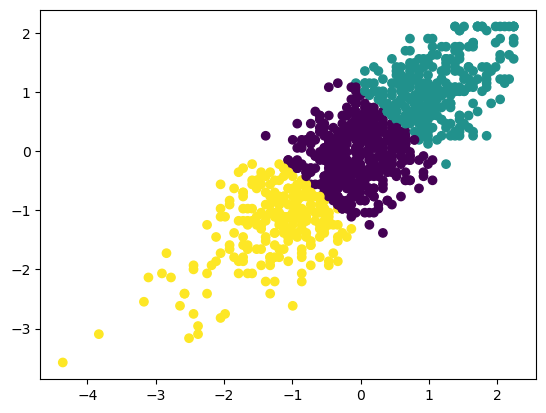

In [23]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],c=labels)

# 14. Visualize Centroids: Plot the centroids on the same graph.

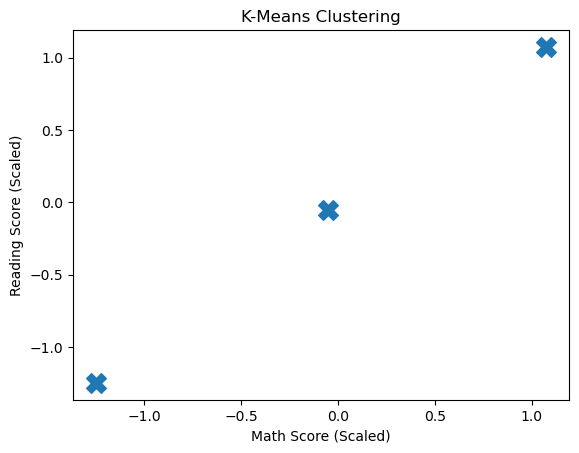

In [34]:
plt.scatter(kmeans.cluster_centers_[:, 0],kmeans.cluster_centers_[:, 1],marker='X',s=200)
plt.xlabel("Math Score (Scaled)")
plt.ylabel("Reading Score (Scaled)")
plt.title("K-Means Clustering")
plt.show()

# 15. Silhouette Score: Calculate the Silhouette Score to evaluate cluster quality.

In [29]:
score = silhouette_score(X_scaled, labels)
score

np.float64(0.4204679825818491)